In [21]:
import pandas as pd

In [22]:
df=pd.read_csv("Dataraw/dataPS.csv")

In [11]:
df.head(5)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [13]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [14]:
df.shape

(6362620, 11)

In [17]:
null_counts=df.isnull().sum()

In [18]:
# Colonnes avec au moins 1 valeur nulle
null_cols = null_counts[null_counts > 0]
print(null_cols)


Series([], dtype: int64)


In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df['nameOrig'].duplicated().sum()

np.int64(9313)

In [21]:
df.columns


Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [22]:
df['amount'].describe()

count    6.362620e+06
mean     1.798619e+05
std      6.038582e+05
min      0.000000e+00
25%      1.338957e+04
50%      7.487194e+04
75%      2.087215e+05
max      9.244552e+07
Name: amount, dtype: float64

In [33]:
import matplotlib.pyplot as plt #stucture et label des graphqiues
import seaborn as sns #creation rapide et jolie de l'histogramme

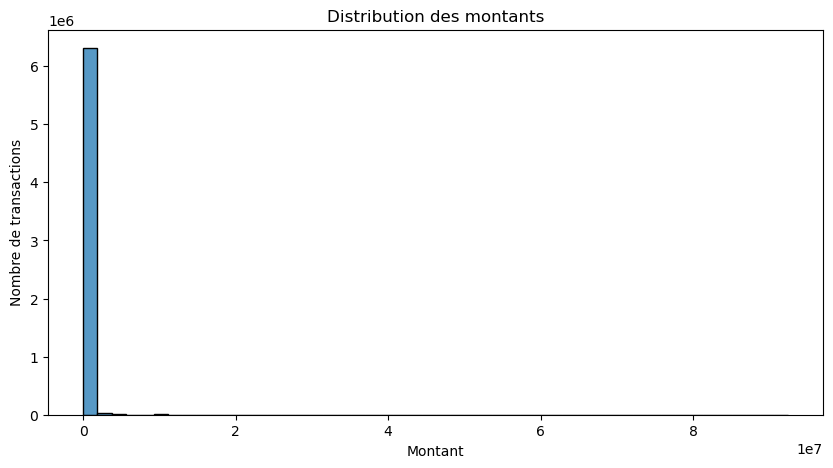

In [27]:
#distribution des montants
#HIST
plt.figure(figsize=(10,5))
sns.histplot(df['amount'], bins=50, kde=False)
plt.title("Distribution des montants")
plt.xlabel("Montant")
plt.ylabel("Nombre de transactions")
plt.show()


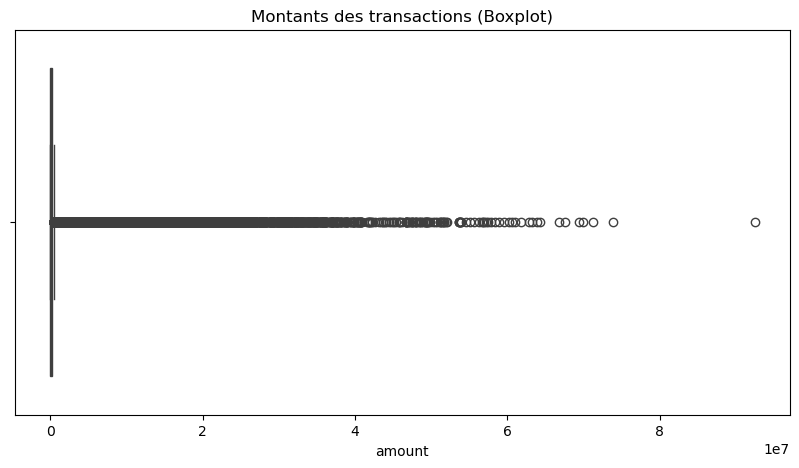

In [28]:
plt.figure(figsize=(10,5))
sns.boxplot(x='amount', data=df)
plt.title("Montants des transactions (Boxplot)")
plt.show()

In [35]:
import numpy as np

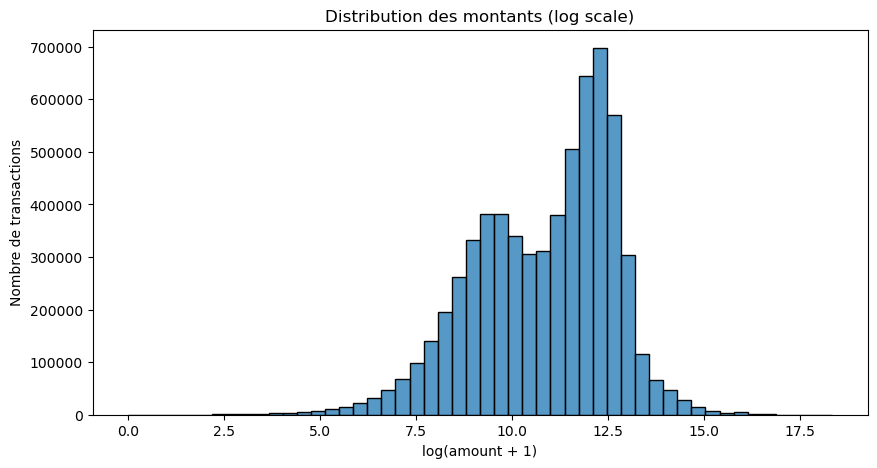

In [32]:
plt.figure(figsize=(10,5))
sns.histplot(np.log1p(df['amount']), bins=50, kde=False)
plt.title("Distribution des montants (log scale)")
plt.xlabel("log(amount + 1)") #les montants varie donc on a fait le log pour voir le montant on fait exp 
plt.ylabel("Nombre de transactions")
plt.show()

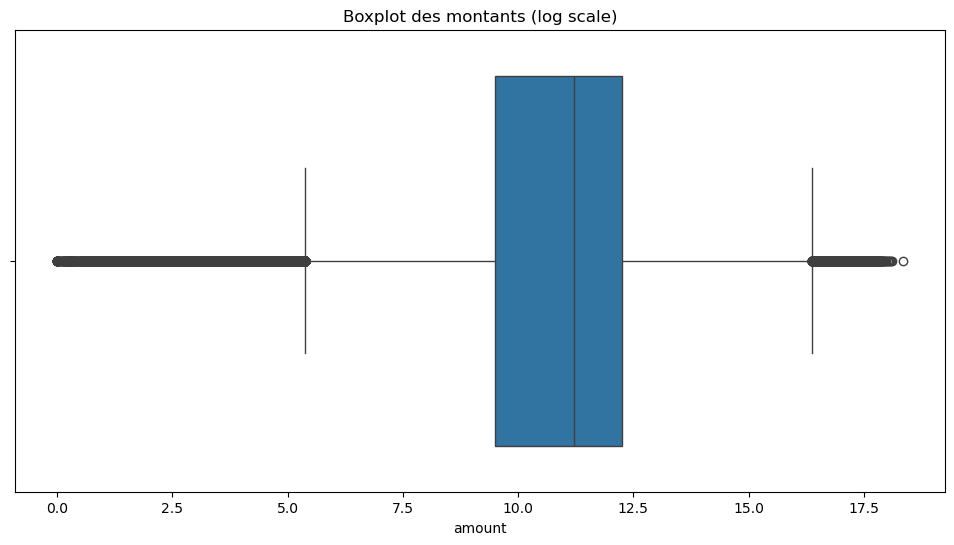

In [35]:
plt.figure(figsize=(12,6))
sns.boxplot(x=np.log1p(df['amount']))  # log(amount + 1) compresse les valeurs grandes et etire les petites
plt.title("Boxplot des montants (log scale)")
plt.show()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64


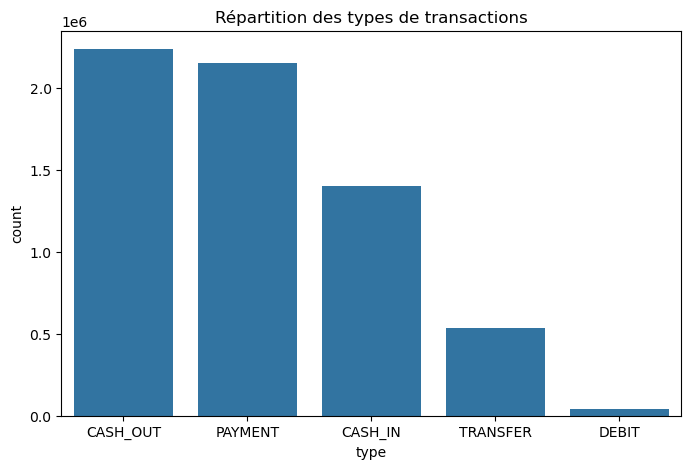

In [36]:
# Compter les types
print(df['type'].value_counts())

# Graphique
plt.figure(figsize=(8,5))
sns.countplot(x='type', data=df, order=df['type'].value_counts().index)
plt.title("Répartition des types de transactions")
plt.show()

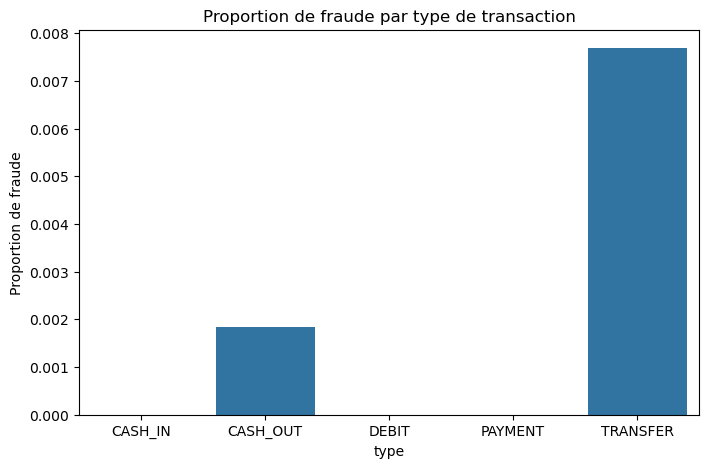

In [38]:
# Pourcentage de fraude par type
fraud_ratio = df.groupby('type')['isFraud'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(x='type', y='isFraud', data=fraud_ratio)
plt.title("Proportion de fraude par type de transaction")
plt.ylabel("Proportion de fraude")
plt.show()

#le type de transaction le plus risque => LE TYPE EST UN FEATURE IMPORTANT

In [39]:
#incoherence solde
# Calculer la différence entre solde avant/après pour l’émetteur
df['diff_orig'] = df['oldbalanceOrg'] - df['newbalanceOrig']

# Vérifier les cas où diff_orig ≠ amount
incoherences = df[df['diff_orig'] != df['amount']]
print("Nombre de transactions incohérentes :", len(incoherences))
#erreur de solde = feature pas indicative pour la fraude

Nombre de transactions incohérentes : 5922109


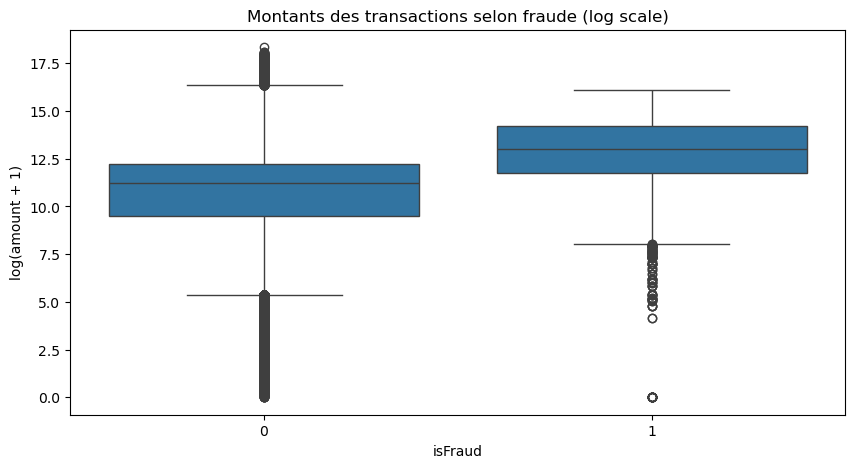

In [41]:
plt.figure(figsize=(10,5))
sns.boxplot(x='isFraud', y=np.log1p(df['amount']), data=df)
plt.title("Montants des transactions selon fraude (log scale)")
plt.ylabel("log(amount + 1)")
plt.show()
#CONCLUSION UN MONTANT TRES ELEVEE PEUT ETRE UN SIGNE DE FRAUDE => Montant est un feature important

In [5]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [3]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
# transformation one-hot
df_encoded = pd.get_dummies(df, columns=['type'], drop_first=True)

In [5]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [6]:
df_encoded.head()

,step,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,False,False,True,False
1,1,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,False,False,True,False
2,1,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,False,False,False,True
3,1,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,True,False,False,False
4,1,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,False,False,True,False


In [7]:
df_encoded = df_encoded.drop(['nameOrig', 'nameDest'], axis=1)

In [8]:
df_encoded.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,170136.0,160296.36,0.0,0.0,0,0,False,False,True,False
1,1,1864.28,21249.0,19384.72,0.0,0.0,0,0,False,False,True,False
2,1,181.00,181.0,0.00,0.0,0.0,1,0,False,False,False,True
3,1,181.00,181.0,0.00,21182.0,0.0,1,0,True,False,False,False
4,1,11668.14,41554.0,29885.86,0.0,0.0,0,0,False,False,True,False


In [9]:
df_encoded.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [10]:
df['diff_orig'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['diff_dest'] = df['newbalanceDest'] - df['oldbalanceDest']

In [11]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,diff_orig,diff_dest
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


In [13]:
df["type"].unique()

array(['PAYMENT', 'TRANSFER', 'CASH_OUT', 'DEBIT', 'CASH_IN'],
      dtype=object)

In [14]:
df = df.drop(['diff_orig', 'diff_dest'], axis=1)

In [15]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [16]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [17]:
# Créer une colonne diff_orig adaptée au type de transaction
df['diff_orig_calc'] = 0.0

# Pour les transactions sortantes
mask_out = df['type'].isin(['CASH_OUT', 'TRANSFER', 'PAYMENT', 'DEBIT'])
df.loc[mask_out, 'diff_orig_calc'] = df['oldbalanceOrg'] - df['newbalanceOrig']

# Pour les transactions entrantes
mask_in = df['type'].isin(['CASH_IN'])
df.loc[mask_in, 'diff_orig_calc'] = df['newbalanceOrig'] - df['oldbalanceOrg']

# Vérifier les incohérences
df['solde_incoherent'] = (abs(df['diff_orig_calc'] - df['amount']) > 1e-6).astype(int)


In [18]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,diff_orig_calc,solde_incoherent
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0


In [19]:
df[df['solde_incoherent'] == 1]['type'].value_counts()

type
CASH_OUT    1998093
PAYMENT     1205652
TRANSFER     509628
CASH_IN      213177
DEBIT         12895
Name: count, dtype: int64

In [20]:
incoherentes = df[df['solde_incoherent'] == 1]
print(incoherentes.head())


    step      type     amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
8      1   PAYMENT    4024.36  C1265012928         2671.0             0.0   
10     1     DEBIT    9644.94  C1900366749         4465.0             0.0   
13     1   PAYMENT   11633.76  C1716932897        10127.0             0.0   
15     1  CASH_OUT  229133.94   C905080434        15325.0             0.0   
16     1   PAYMENT    1563.82   C761750706          450.0             0.0   

       nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  \
8   M1176932104             0.0            0.00        0               0   
10   C997608398         10845.0       157982.12        0               0   
13   M801569151             0.0            0.00        0               0   
15   C476402209          5083.0        51513.44        0               0   
16  M1731217984             0.0            0.00        0               0   

    diff_orig_calc  solde_incoherent  
8           2671.0                 1  
10

In [21]:
pd.crosstab(df['solde_incoherent'], df['isFraud'])


isFraud,0,1
solde_incoherent,,
0,2415007,8168
1,3939400,45


In [23]:
df[df["isFraud"] == 1].shape[0]   # nombre de transactions frauduleuses


8213

In [24]:
df.drop(columns=['solde_incoherent'], inplace=True)


In [3]:
df_encoded.head()

NameError: name 'df_encoded' is not defined

In [4]:
df_encoded=pd.read_csv("Dataraw/dataPS.csv")

In [5]:
df_encoded.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [6]:
df_encoded=df_encoded.drop(columns=["isFlaggedFraud"])

In [7]:
df_encoded.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0


In [8]:
df_encoded = pd.get_dummies(df_encoded, columns=['type'], drop_first=True)


In [9]:
df_encoded.head()

,step,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,False,False,True,False
1,1,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,False,False,True,False
2,1,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,False,False,False,True
3,1,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,True,False,False,False
4,1,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,False,False,True,False


In [10]:
df_encoded=df_encoded.drop(columns=["nameOrig","nameDest"])

In [14]:
df_encoded.head()

,step,amount,oldbalanceOrg,newbalanceOrig,isFraud,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,170136.0,160296.36,0,False,False,True,False
1,1,1864.28,21249.0,19384.72,0,False,False,True,False
2,1,181.00,181.0,0.00,1,False,False,False,True
3,1,181.00,181.0,0.00,1,True,False,False,False
4,1,11668.14,41554.0,29885.86,0,False,False,True,False


In [12]:
df_encoded=df_encoded.drop(columns=["oldbalanceDest","newbalanceDest"])

In [13]:
df_encoded.head()

,step,amount,oldbalanceOrg,newbalanceOrig,isFraud,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,170136.0,160296.36,0,False,False,True,False
1,1,1864.28,21249.0,19384.72,0,False,False,True,False
2,1,181.00,181.0,0.00,1,False,False,False,True
3,1,181.00,181.0,0.00,1,True,False,False,False
4,1,11668.14,41554.0,29885.86,0,False,False,True,False


In [15]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [16]:
df=df.drop(columns=["isFlaggedFraud"])

In [17]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0


In [18]:
df=df.drop(columns=["nameOrig","nameDest"])

In [26]:
df = pd.get_dummies(df, columns=['type'], drop_first=True)


In [20]:
df.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,170136.0,160296.36,0.0,0.0,0,False,False,True,False
1,1,1864.28,21249.0,19384.72,0.0,0.0,0,False,False,True,False
2,1,181.00,181.0,0.00,0.0,0.0,1,False,False,False,True
3,1,181.00,181.0,0.00,21182.0,0.0,1,True,False,False,False
4,1,11668.14,41554.0,29885.86,0.0,0.0,0,False,False,True,False


In [21]:
df[numerical_cols].describe()

NameError: name 'numerical_cols' is not defined

In [22]:
df.corr()["isFraud"].sort_values(ascending=False)

isFraud           1.000000
amount            0.076688
type_TRANSFER     0.053869
step              0.031578
type_CASH_OUT     0.011256
oldbalanceOrg     0.010154
newbalanceDest    0.000535
type_DEBIT       -0.002911
oldbalanceDest   -0.005885
newbalanceOrig   -0.008148
type_PAYMENT     -0.025697
Name: isFraud, dtype: float64

In [27]:
df["is_suspicious_type"] = df["type_TRANSFER"] | df["type_CASH_OUT"]

In [28]:
df["ratio_amount_balance"] = df["amount"] / (df["oldbalanceOrg"] + 1)

In [3]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [26]:
df["day"] = df["step"] // 24
df["hour"] = df["step"] % 24

In [27]:
df.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,is_suspicious_type,ratio_amount_balance,day,hour
0,1,9839.64,170136.0,160296.36,0.0,0.0,0,False,False,True,False,False,0.057834,0,1
1,1,1864.28,21249.0,19384.72,0.0,0.0,0,False,False,True,False,False,0.087731,0,1
2,1,181.00,181.0,0.00,0.0,0.0,1,False,False,False,True,True,0.994505,0,1
3,1,181.00,181.0,0.00,21182.0,0.0,1,True,False,False,False,True,0.994505,0,1
4,1,11668.14,41554.0,29885.86,0.0,0.0,0,False,False,True,False,False,0.280788,0,1


In [29]:
df.drop(columns=["day","hour"])

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,is_suspicious_type,ratio_amount_balance
0,1,9839.64,170136.00,160296.36,0.00,0.00,0,False,False,True,False,False,0.057834
1,1,1864.28,21249.00,19384.72,0.00,0.00,0,False,False,True,False,False,0.087731
2,1,181.00,181.00,0.00,0.00,0.00,1,False,False,False,True,True,0.994505
3,1,181.00,181.00,0.00,21182.00,0.00,1,True,False,False,False,True,0.994505
4,1,11668.14,41554.00,29885.86,0.00,0.00,0,False,False,True,False,False,0.280788
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,339682.13,339682.13,0.00,0.00,339682.13,1,True,False,False,False,True,0.999997
6362616,743,6311409.28,6311409.28,0.00,0.00,0.00,1,False,False,False,True,True,1.000000
6362617,743,6311409.28,6311409.28,0.00,68488.84,6379898.11,1,True,False,False,False,True,1.000000
6362618,743,850002.52,850002.52,0.00,0.00,0.00,1,False,False,False,True,True,0.999999


In [30]:
df["delta_balance_org"] = df["oldbalanceOrg"] - df["newbalanceOrig"]

In [31]:
df

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,is_suspicious_type,ratio_amount_balance,day,hour,delta_balance_org
0,1,9839.64,170136.00,160296.36,0.00,0.00,0,False,False,True,False,False,0.057834,0,1,9839.64
1,1,1864.28,21249.00,19384.72,0.00,0.00,0,False,False,True,False,False,0.087731,0,1,1864.28
2,1,181.00,181.00,0.00,0.00,0.00,1,False,False,False,True,True,0.994505,0,1,181.00
3,1,181.00,181.00,0.00,21182.00,0.00,1,True,False,False,False,True,0.994505,0,1,181.00
4,1,11668.14,41554.00,29885.86,0.00,0.00,0,False,False,True,False,False,0.280788,0,1,11668.14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,339682.13,339682.13,0.00,0.00,339682.13,1,True,False,False,False,True,0.999997,30,23,339682.13
6362616,743,6311409.28,6311409.28,0.00,0.00,0.00,1,False,False,False,True,True,1.000000,30,23,6311409.28
6362617,743,6311409.28,6311409.28,0.00,68488.84,6379898.11,1,True,False,False,False,True,1.000000,30,23,6311409.28
6362618,743,850002.52,850002.52,0.00,0.00,0.00,1,False,False,False,True,True,0.999999,30,23,850002.52


C:\Users\hassa\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


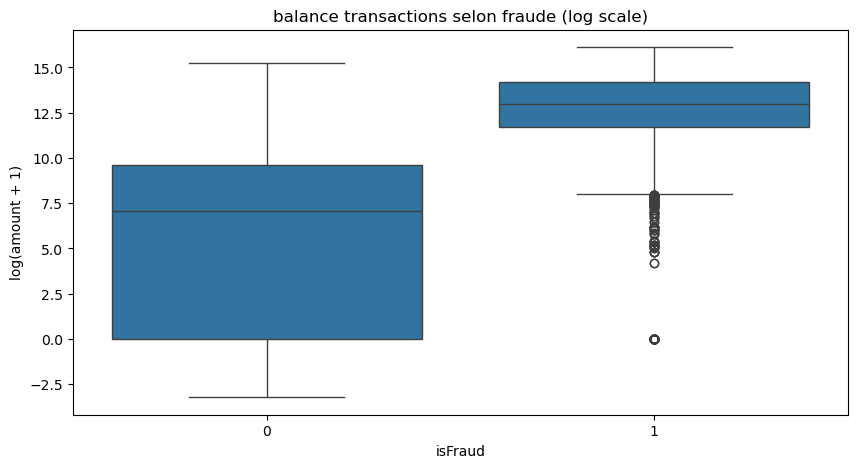

In [36]:
plt.figure(figsize=(10,5))
sns.boxplot(x='isFraud', y=np.log1p(df['delta_balance_org']), data=df)
plt.title("balance transactions selon fraude (log scale)")
plt.ylabel("log(amount + 1)")
plt.show()

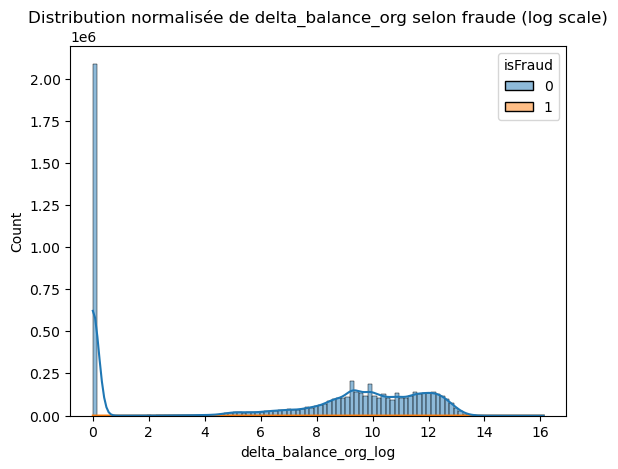

In [39]:
df['delta_balance_org_log'] = np.log1p(np.abs(df['delta_balance_org']))
sns.histplot(data=df, x='delta_balance_org_log', hue='isFraud', bins=100, kde=True)
plt.title("Distribution normalisée de delta_balance_org selon fraude (log scale)")
plt.show()

In [40]:
df.drop(columns=["delta_balance_org_log"])

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,is_suspicious_type,ratio_amount_balance,day,hour,delta_balance_org
0,1,9839.64,170136.00,160296.36,0.00,0.00,0,False,False,True,False,False,0.057834,0,1,9839.64
1,1,1864.28,21249.00,19384.72,0.00,0.00,0,False,False,True,False,False,0.087731,0,1,1864.28
2,1,181.00,181.00,0.00,0.00,0.00,1,False,False,False,True,True,0.994505,0,1,181.00
3,1,181.00,181.00,0.00,21182.00,0.00,1,True,False,False,False,True,0.994505,0,1,181.00
4,1,11668.14,41554.00,29885.86,0.00,0.00,0,False,False,True,False,False,0.280788,0,1,11668.14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,339682.13,339682.13,0.00,0.00,339682.13,1,True,False,False,False,True,0.999997,30,23,339682.13
6362616,743,6311409.28,6311409.28,0.00,0.00,0.00,1,False,False,False,True,True,1.000000,30,23,6311409.28
6362617,743,6311409.28,6311409.28,0.00,68488.84,6379898.11,1,True,False,False,False,True,1.000000,30,23,6311409.28
6362618,743,850002.52,850002.52,0.00,0.00,0.00,1,False,False,False,True,True,0.999999,30,23,850002.52


In [44]:
df[df["delta_balance_org"] < 0 & df["type_CASH_OUT"]]

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,is_suspicious_type,ratio_amount_balance,day,hour,delta_balance_org,delta_balance_org_log
389,1,143236.26,0.00,143236.26,608932.17,97263.78,0,False,False,False,False,False,143236.260000,0,1,-143236.26,11.872258
390,1,228451.89,143236.26,371688.15,719678.38,1186556.81,0,False,False,False,False,False,1.594919,0,1,-228451.89,12.339085
391,1,35902.49,371688.15,407590.65,49003.30,0.00,0,False,False,False,False,False,0.096593,0,1,-35902.50,10.488590
392,1,232953.64,407590.65,640544.28,1172672.27,1517262.16,0,False,False,False,False,False,0.571537,0,1,-232953.63,12.358599
393,1,65912.95,640544.28,706457.23,104198.26,24044.18,0,False,False,False,False,False,0.102901,0,1,-65912.95,11.096105
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362253,718,188888.89,51838.00,240726.89,0.00,0.00,0,False,False,False,False,False,3.643760,29,22,-188888.89,12.148920
6362271,718,27919.60,2413.00,30332.60,512791.59,484871.98,0,False,False,False,False,False,11.565700,29,22,-27919.60,10.237120
6362279,718,78988.38,204464.00,283452.38,108724.19,29735.81,0,False,False,False,False,False,0.386317,29,22,-78988.38,11.277069
6362298,718,18000.26,63409.00,81409.26,28088.61,10088.34,0,False,False,False,False,False,0.283871,29,22,-18000.26,9.798197


In [3]:
df.head(10)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.0,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.0,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.0,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.0,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.0,0.00,0,0
5,1,PAYMENT,7817.71,C90045638,53860.00,46042.29,M573487274,0.0,0.00,0,0
6,1,PAYMENT,7107.77,C154988899,183195.00,176087.23,M408069119,0.0,0.00,0,0
7,1,PAYMENT,7861.64,C1912850431,176087.23,168225.59,M633326333,0.0,0.00,0,0
8,1,PAYMENT,4024.36,C1265012928,2671.00,0.00,M1176932104,0.0,0.00,0,0
9,1,DEBIT,5337.77,C712410124,41720.00,36382.23,C195600860,41898.0,40348.79,0,0


In [4]:
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


In [25]:
df.drop(columns=['nameOrig','nameDest','isFlaggedFraud'], axis=1, inplace=True)

In [6]:
df

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
0,1,PAYMENT,9839.64,170136.00,160296.36,0.00,0.00,0
1,1,PAYMENT,1864.28,21249.00,19384.72,0.00,0.00,0
2,1,TRANSFER,181.00,181.00,0.00,0.00,0.00,1
3,1,CASH_OUT,181.00,181.00,0.00,21182.00,0.00,1
4,1,PAYMENT,11668.14,41554.00,29885.86,0.00,0.00,0
...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,339682.13,0.00,0.00,339682.13,1
6362616,743,TRANSFER,6311409.28,6311409.28,0.00,0.00,0.00,1
6362617,743,CASH_OUT,6311409.28,6311409.28,0.00,68488.84,6379898.11,1
6362618,743,TRANSFER,850002.52,850002.52,0.00,0.00,0.00,1


In [10]:
df

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,is_suspicious_type
0,1,9839.64,170136.00,160296.36,0.00,0.00,0,False,False,True,False,False
1,1,1864.28,21249.00,19384.72,0.00,0.00,0,False,False,True,False,False
2,1,181.00,181.00,0.00,0.00,0.00,1,False,False,False,True,True
3,1,181.00,181.00,0.00,21182.00,0.00,1,True,False,False,False,True
4,1,11668.14,41554.00,29885.86,0.00,0.00,0,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,339682.13,339682.13,0.00,0.00,339682.13,1,True,False,False,False,True
6362616,743,6311409.28,6311409.28,0.00,0.00,0.00,1,False,False,False,True,True
6362617,743,6311409.28,6311409.28,0.00,68488.84,6379898.11,1,True,False,False,False,True
6362618,743,850002.52,850002.52,0.00,0.00,0.00,1,False,False,False,True,True


In [12]:
df

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,is_suspicious_type,ratio_amount_balance
0,1,9839.64,170136.00,160296.36,0.00,0.00,0,False,False,True,False,False,0.057834
1,1,1864.28,21249.00,19384.72,0.00,0.00,0,False,False,True,False,False,0.087731
2,1,181.00,181.00,0.00,0.00,0.00,1,False,False,False,True,True,0.994505
3,1,181.00,181.00,0.00,21182.00,0.00,1,True,False,False,False,True,0.994505
4,1,11668.14,41554.00,29885.86,0.00,0.00,0,False,False,True,False,False,0.280788
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,339682.13,339682.13,0.00,0.00,339682.13,1,True,False,False,False,True,0.999997
6362616,743,6311409.28,6311409.28,0.00,0.00,0.00,1,False,False,False,True,True,1.000000
6362617,743,6311409.28,6311409.28,0.00,68488.84,6379898.11,1,True,False,False,False,True,1.000000
6362618,743,850002.52,850002.52,0.00,0.00,0.00,1,False,False,False,True,True,0.999999


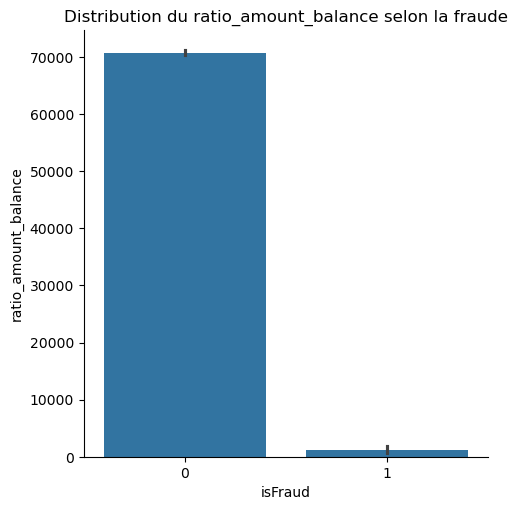

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.catplot(x='isFraud', y='ratio_amount_balance', kind='bar', data=df)
plt.title("Distribution du ratio_amount_balance selon la fraude")
plt.show()

In [10]:
df

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,is_suspicious_type,ratio_amount_balance
0,1,9839.64,170136.00,160296.36,0.00,0.00,0,False,False,True,False,False,0.057834
1,1,1864.28,21249.00,19384.72,0.00,0.00,0,False,False,True,False,False,0.087731
2,1,181.00,181.00,0.00,0.00,0.00,1,False,False,False,True,True,0.994505
3,1,181.00,181.00,0.00,21182.00,0.00,1,True,False,False,False,True,0.994505
4,1,11668.14,41554.00,29885.86,0.00,0.00,0,False,False,True,False,False,0.280788
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,339682.13,339682.13,0.00,0.00,339682.13,1,True,False,False,False,True,0.999997
6362616,743,6311409.28,6311409.28,0.00,0.00,0.00,1,False,False,False,True,True,1.000000
6362617,743,6311409.28,6311409.28,0.00,68488.84,6379898.11,1,True,False,False,False,True,1.000000
6362618,743,850002.52,850002.52,0.00,0.00,0.00,1,False,False,False,True,True,0.999999


In [24]:
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


In [29]:
df

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,is_suspicious_type,ratio_amount_balance
0,1,9839.64,170136.00,160296.36,0.00,0.00,0,False,False,True,False,False,0.057834
1,1,1864.28,21249.00,19384.72,0.00,0.00,0,False,False,True,False,False,0.087731
2,1,181.00,181.00,0.00,0.00,0.00,1,False,False,False,True,True,0.994505
3,1,181.00,181.00,0.00,21182.00,0.00,1,True,False,False,False,True,0.994505
4,1,11668.14,41554.00,29885.86,0.00,0.00,0,False,False,True,False,False,0.280788
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,339682.13,339682.13,0.00,0.00,339682.13,1,True,False,False,False,True,0.999997
6362616,743,6311409.28,6311409.28,0.00,0.00,0.00,1,False,False,False,True,True,1.000000
6362617,743,6311409.28,6311409.28,0.00,68488.84,6379898.11,1,True,False,False,False,True,1.000000
6362618,743,850002.52,850002.52,0.00,0.00,0.00,1,False,False,False,True,True,0.999999


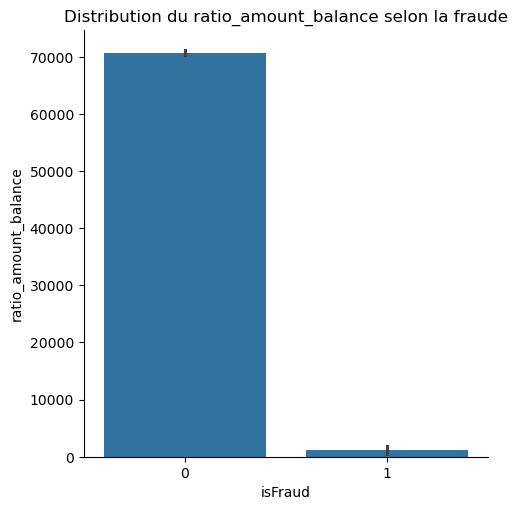

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.catplot(x='isFraud', y='ratio_amount_balance', kind='bar', data=df)
plt.title("Distribution du ratio_amount_balance selon la fraude")
plt.show()

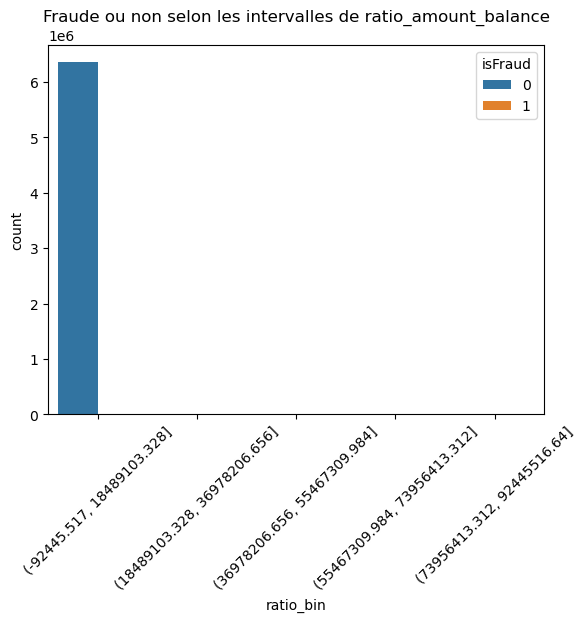

In [31]:
df['ratio_bin'] = pd.cut(df['ratio_amount_balance'], bins=5)  # 5 intervalles
sns.countplot(x='ratio_bin', hue='isFraud', data=df)
plt.title("Fraude ou non selon les intervalles de ratio_amount_balance")
plt.xticks(rotation=45)
plt.show()


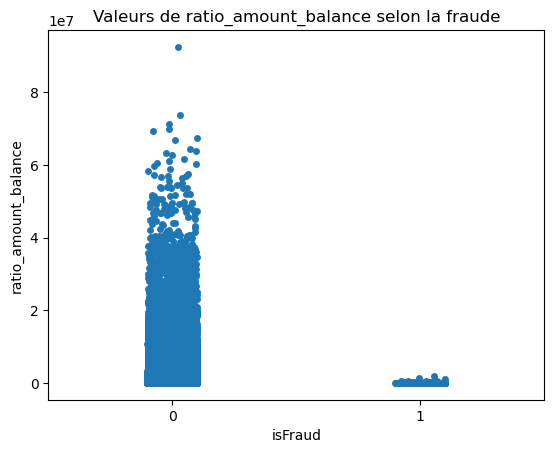

In [33]:
sns.stripplot(x='isFraud', y='ratio_amount_balance', data=df, jitter=True)
plt.title("Valeurs de ratio_amount_balance selon la fraude")
plt.xlabel("isFraud")
plt.ylabel("ratio_amount_balance")
plt.show()

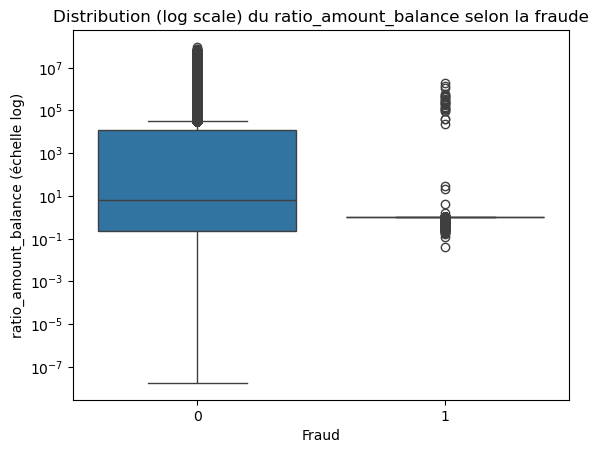

In [35]:
sns.boxplot(x='isFraud', y='ratio_amount_balance', data=df)
plt.yscale('log')
plt.title("Distribution (log scale) du ratio_amount_balance selon la fraude")
plt.xlabel("Fraud")
plt.ylabel("ratio_amount_balance (échelle log)")
plt.show()

C:\Users\hassa\AppData\Local\Temp\ipykernel_20004\3414330163.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  count_df = df.groupby(['ratio_category', 'isFraud']).size().reset_index(name='count')


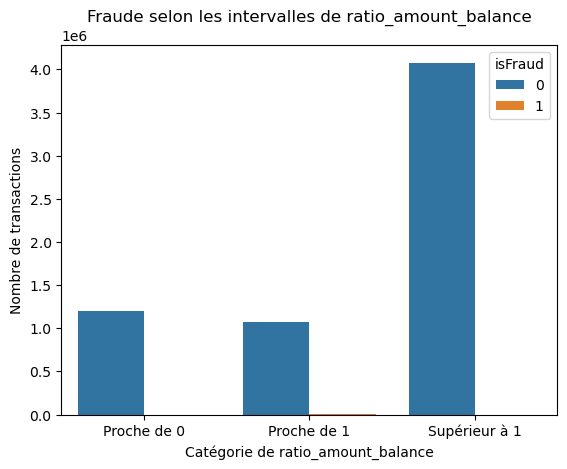

In [36]:
bins = [-float('inf'), 0.1, 1, float('inf')]
labels = ["Proche de 0", "Proche de 1", "Supérieur à 1"]
df['ratio_category'] = pd.cut(df['ratio_amount_balance'], bins=bins, labels=labels)
count_df = df.groupby(['ratio_category', 'isFraud']).size().reset_index(name='count')
sns.barplot(x='ratio_category', y='count', hue='isFraud', data=count_df)
plt.title("Fraude selon les intervalles de ratio_amount_balance")
plt.xlabel("Catégorie de ratio_amount_balance")
plt.ylabel("Nombre de transactions")
plt.show()

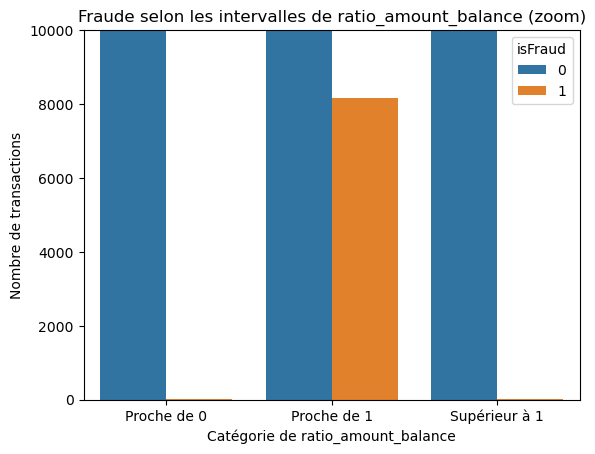

In [47]:
sns.barplot(x='ratio_category', y='count', hue='isFraud', data=count_df)
plt.ylim(0, 10000)  
plt.title("Fraude selon les intervalles de ratio_amount_balance (zoom)")
plt.xlabel("Catégorie de ratio_amount_balance")
plt.ylabel("Nombre de transactions")
plt.show()

C:\Users\hassa\AppData\Local\Temp\ipykernel_20004\852756472.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  count_df = df.groupby(['ratio_category', 'isFraud']).size().reset_index(name='count')
C:\Users\hassa\AppData\Local\Temp\ipykernel_20004\852756472.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total_df = df.groupby('ratio_category').size().reset_index(name='total')


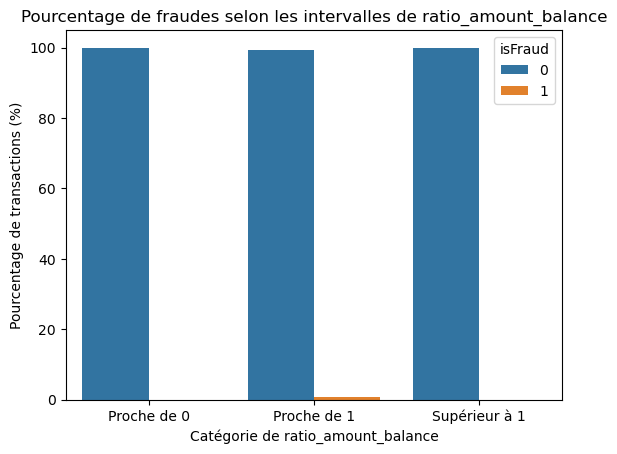

In [44]:
# Comptage par catégorie
count_df = df.groupby(['ratio_category', 'isFraud']).size().reset_index(name='count')
# Total par catégorie
total_df = df.groupby('ratio_category').size().reset_index(name='total')
# Fusionner et calculer le pourcentage
merged_df = count_df.merge(total_df, on='ratio_category')
merged_df['percent'] = merged_df['count'] / merged_df['total'] * 100
sns.barplot(x='ratio_category', y='percent', hue='isFraud', data=merged_df)
plt.title("Pourcentage de fraudes selon les intervalles de ratio_amount_balance")
plt.xlabel("Catégorie de ratio_amount_balance")
plt.ylabel("Pourcentage de transactions (%)")
plt.show()

In [48]:
df

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,is_suspicious_type,ratio_amount_balance,ratio_bin,ratio_category
0,1,9839.64,170136.00,160296.36,0.00,0.00,0,False,False,True,False,False,0.057834,"(-92445.517, 18489103.328]",Proche de 0
1,1,1864.28,21249.00,19384.72,0.00,0.00,0,False,False,True,False,False,0.087731,"(-92445.517, 18489103.328]",Proche de 0
2,1,181.00,181.00,0.00,0.00,0.00,1,False,False,False,True,True,0.994505,"(-92445.517, 18489103.328]",Proche de 1
3,1,181.00,181.00,0.00,21182.00,0.00,1,True,False,False,False,True,0.994505,"(-92445.517, 18489103.328]",Proche de 1
4,1,11668.14,41554.00,29885.86,0.00,0.00,0,False,False,True,False,False,0.280788,"(-92445.517, 18489103.328]",Proche de 1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,339682.13,339682.13,0.00,0.00,339682.13,1,True,False,False,False,True,0.999997,"(-92445.517, 18489103.328]",Proche de 1
6362616,743,6311409.28,6311409.28,0.00,0.00,0.00,1,False,False,False,True,True,1.000000,"(-92445.517, 18489103.328]",Proche de 1
6362617,743,6311409.28,6311409.28,0.00,68488.84,6379898.11,1,True,False,False,False,True,1.000000,"(-92445.517, 18489103.328]",Proche de 1
6362618,743,850002.52,850002.52,0.00,0.00,0.00,1,False,False,False,True,True,0.999999,"(-92445.517, 18489103.328]",Proche de 1


In [50]:
df=df.drop(columns=["ratio_bin","ratio_category"])

In [51]:
df

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,is_suspicious_type,ratio_amount_balance
0,1,9839.64,170136.00,160296.36,0.00,0.00,0,False,False,True,False,False,0.057834
1,1,1864.28,21249.00,19384.72,0.00,0.00,0,False,False,True,False,False,0.087731
2,1,181.00,181.00,0.00,0.00,0.00,1,False,False,False,True,True,0.994505
3,1,181.00,181.00,0.00,21182.00,0.00,1,True,False,False,False,True,0.994505
4,1,11668.14,41554.00,29885.86,0.00,0.00,0,False,False,True,False,False,0.280788
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,339682.13,339682.13,0.00,0.00,339682.13,1,True,False,False,False,True,0.999997
6362616,743,6311409.28,6311409.28,0.00,0.00,0.00,1,False,False,False,True,True,1.000000
6362617,743,6311409.28,6311409.28,0.00,68488.84,6379898.11,1,True,False,False,False,True,1.000000
6362618,743,850002.52,850002.52,0.00,0.00,0.00,1,False,False,False,True,True,0.999999


In [54]:
df.to_csv("dataClean.csv")

In [55]:
df=pd.read_csv("dataClean.csv")

In [56]:
df

,Unnamed: 0,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,is_suspicious_type,ratio_amount_balance
0,0,1,9839.64,170136.00,160296.36,0.00,0.00,0,False,False,True,False,False,0.057834
1,1,1,1864.28,21249.00,19384.72,0.00,0.00,0,False,False,True,False,False,0.087731
2,2,1,181.00,181.00,0.00,0.00,0.00,1,False,False,False,True,True,0.994505
3,3,1,181.00,181.00,0.00,21182.00,0.00,1,True,False,False,False,True,0.994505
4,4,1,11668.14,41554.00,29885.86,0.00,0.00,0,False,False,True,False,False,0.280788
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,6362615,743,339682.13,339682.13,0.00,0.00,339682.13,1,True,False,False,False,True,0.999997
6362616,6362616,743,6311409.28,6311409.28,0.00,0.00,0.00,1,False,False,False,True,True,1.000000
6362617,6362617,743,6311409.28,6311409.28,0.00,68488.84,6379898.11,1,True,False,False,False,True,1.000000
6362618,6362618,743,850002.52,850002.52,0.00,0.00,0.00,1,False,False,False,True,True,0.999999
